# Class 11: Quantum Reservoir Computing (Solutions)

**ZHAW Quantum Machine Learning Course**

**Convention:** All qubits start in state |0> unless otherwise specified.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.linear_model import Ridge
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---

## Math Task M11.1

For a single-qubit reservoir: input x -> Rx(x) applied to current state. For a time series [x1, x2, ..., xt], show reservoir state after 2 steps starting from |0>. Apply Rx(x1), then Rx(x2), and compute expectation values.

In [2]:
print("Single-qubit reservoir encoding:")
print("")
print("Initial state: |psi_0> = |0>")
print("")
print("After step 1 (input x1):")
print("  Apply Rx(x1): |psi_1> = Rx(x1)|0> = cos(x1/2)|0> - i*sin(x1/2)|1>")
print("")
print("After step 2 (input x2):")
print("  Apply Rx(x2) to |psi_1>")
print("  |psi_2> = Rx(x2) Rx(x1)|0>")
print("")
print("The reservoir state encodes history via matrix exponentials.")

x1 = 0.5
x2 = 0.3

def rx_matrix(angle):
    return np.array([
        [np.cos(angle/2), -1j*np.sin(angle/2)],
        [-1j*np.sin(angle/2), np.cos(angle/2)]
    ])

psi_0 = np.array([1, 0])
psi_1 = rx_matrix(x1) @ psi_0
psi_2 = rx_matrix(x2) @ psi_1

print(f"\nNumerical result for x1={x1}, x2={x2}:")
print(f"|psi_1> = {np.around(psi_1, 4)}")
print(f"|psi_2> = {np.around(psi_2, 4)}")

X_matrix = np.array([[0, 1], [1, 0]])
Y_matrix = np.array([[0, -1j], [1j, 0]])
Z_matrix = np.array([[1, 0], [0, -1]])

exp_X_2 = np.real(np.conj(psi_2) @ X_matrix @ psi_2)
exp_Y_2 = np.real(np.conj(psi_2) @ Y_matrix @ psi_2)
exp_Z_2 = np.real(np.conj(psi_2) @ Z_matrix @ psi_2)

print(f"\nExpectation values after 2 steps:")
print(f"<X> = {exp_X_2:.6f}")
print(f"<Y> = {exp_Y_2:.6f}")
print(f"<Z> = {exp_Z_2:.6f}")

Single-qubit reservoir encoding:

Initial state: |psi_0> = |0>

After step 1 (input x1):
  Apply Rx(x1): |psi_1> = Rx(x1)|0> = cos(x1/2)|0> - i*sin(x1/2)|1>

After step 2 (input x2):
  Apply Rx(x2) to |psi_1>
  |psi_2> = Rx(x2) Rx(x1)|0>

The reservoir state encodes history via matrix exponentials.

Numerical result for x1=0.5, x2=0.3:
|psi_1> = [0.9689+0.j     0.    -0.2474j]
|psi_2> = [0.9211+0.j     0.    -0.3894j]

Expectation values after 2 steps:
<X> = 0.000000
<Y> = -0.717356
<Z> = 0.696707


---

## Math Task M11.2

In a QELM with 3 qubits, count the number of weight-1 and weight-2 Pauli expectations.

In [3]:
n_qubits = 3

weight_1_count = n_qubits * 3

weight_2_count = len(list(range(n_qubits))) * (len(list(range(n_qubits))) - 1) // 2 * 9

total_features = weight_1_count + weight_2_count

print(f"QELM Feature Count for n={n_qubits} qubits:")
print(f"\nWeight-1 Pauli expectations (X, Y, Z on each qubit):")
print(f"  Count = {n_qubits} qubits * 3 observables = {weight_1_count}")

print(f"\nWeight-2 Pauli expectations (pairs of observables on 2-qubit subsets):")
print(f"  Number of qubit pairs = C({n_qubits}, 2) = {len(list(range(n_qubits))) * (len(list(range(n_qubits))) - 1) // 2}")
print(f"  Pauli pairs per subset = 3 * 3 = 9")
print(f"  Count = {len(list(range(n_qubits))) * (len(list(range(n_qubits))) - 1) // 2} * 9 = {weight_2_count}")

print(f"\nTotal feature count = {weight_1_count} + {weight_2_count} = {total_features}")

QELM Feature Count for n=3 qubits:

Weight-1 Pauli expectations (X, Y, Z on each qubit):
  Count = 3 qubits * 3 observables = 9

Weight-2 Pauli expectations (pairs of observables on 2-qubit subsets):
  Number of qubit pairs = C(3, 2) = 3
  Pauli pairs per subset = 3 * 3 = 9
  Count = 3 * 9 = 27

Total feature count = 9 + 27 = 36


---

## Programming Task P11.1: Quantum Reservoir for Time Series Prediction

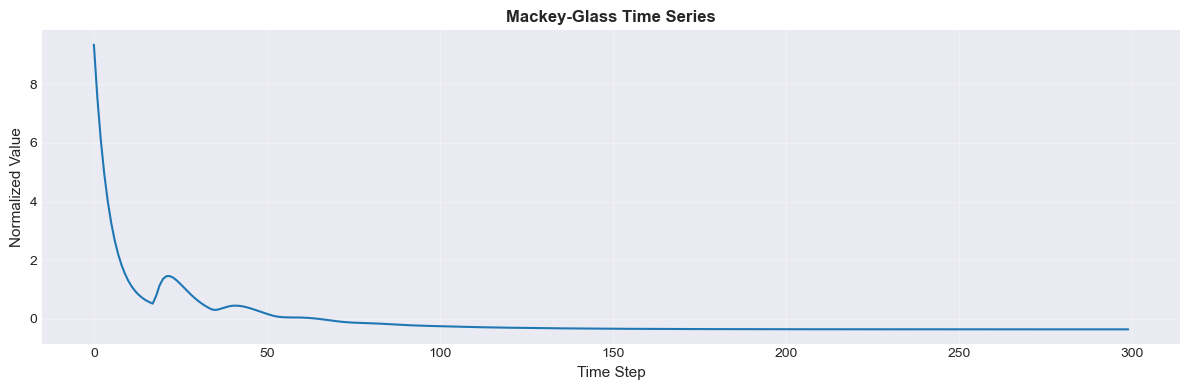

Time series shape: (300,)
Mean: 0.000000, Std: 1.000000


In [4]:
def mackey_glass(n_steps=1000, a=0.1, b=0.2, tau=17.0, x0=1.2):
    x = np.zeros(n_steps)
    x[0] = x0
    for t in range(1, n_steps):
        tau_idx = max(0, t - int(tau))
        x[t] = x[t-1] + (a * x[tau_idx] / (1.0 + x[tau_idx]**10) - b * x[t-1])
    return x

time_series = mackey_glass(n_steps=300)
time_series = (time_series - np.mean(time_series)) / np.std(time_series)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_series, linewidth=1.5)
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Normalized Value', fontsize=11)
ax.set_title('Mackey-Glass Time Series', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Time series shape: {time_series.shape}")
print(f"Mean: {np.mean(time_series):.6f}, Std: {np.std(time_series):.6f}")

In [5]:
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def quantum_reservoir(input_val, reservoir_state):
    for i in range(n_qubits):
        qml.RY(reservoir_state[i], wires=i)
    
    qml.RY(input_val, wires=0)
    
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

np.random.seed(42)
initial_state = np.zeros(n_qubits)
test_input = time_series[50]
features = quantum_reservoir(test_input, initial_state)

print(f"Reservoir features shape: {len(features)}")
print(f"Sample features: {np.around(np.array(features), 4)}")

Reservoir features shape: 4
Sample features: [0.9847 0.9847 0.9847 0.9847]


In [6]:
X_train = []
y_train = []

reservoir_state = np.zeros(n_qubits)

for t in range(50, 250):
    features = quantum_reservoir(time_series[t], reservoir_state)
    X_train.append(features)
    y_train.append(time_series[t+1])
    
    reservoir_state = np.array(features)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Training set shape: {X_train.shape}")
print(f"Training targets shape: {y_train.shape}")

Training set shape: (200, 4)
Training targets shape: (200,)


In [7]:
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

X_test = []
y_test = []

for t in range(250, 299):
    features = quantum_reservoir(time_series[t], reservoir_state)
    X_test.append(features)
    y_test.append(time_series[t+1])
    
    reservoir_state = np.array(features)

X_test = np.array(X_test)
y_test = np.array(y_test)

y_pred = ridge.predict(X_test)

mse = np.mean((y_pred - y_test) ** 2)
nmse = mse / np.var(y_test)

print(f"Test set shape: {X_test.shape}")
print(f"NMSE: {nmse:.6f}")
print(f"MSE: {mse:.6f}")

Test set shape: (49, 4)
NMSE: 17435.965987
MSE: 0.000579


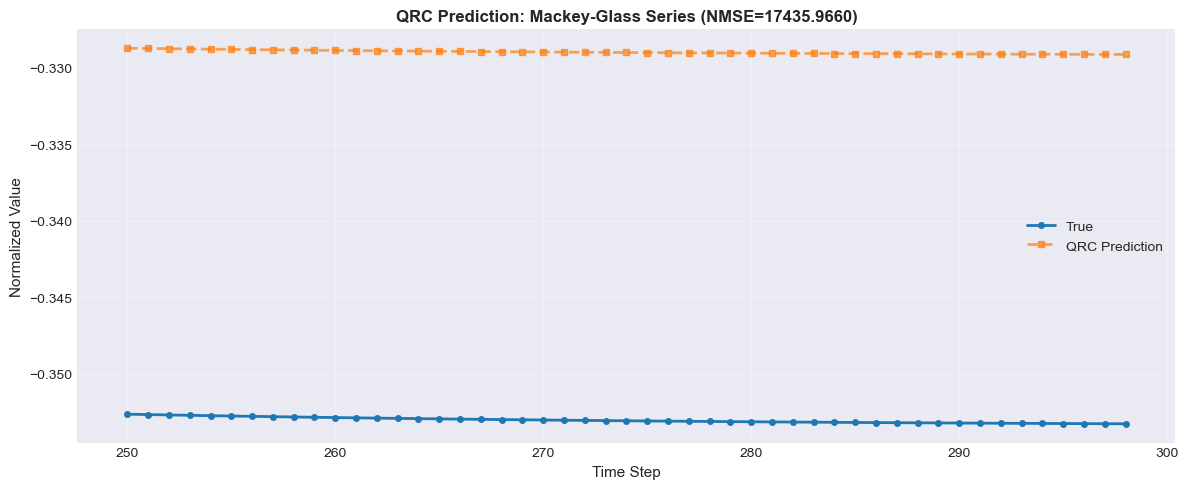

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

test_range = np.arange(250, 299)
ax.plot(test_range, y_test, 'o-', label='True', linewidth=2, markersize=4)
ax.plot(test_range, y_pred, 's--', label='QRC Prediction', linewidth=2, markersize=4, alpha=0.7)

ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Normalized Value', fontsize=11)
ax.set_title(f'QRC Prediction: Mackey-Glass Series (NMSE={nmse:.4f})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Programming Task P11.2: QELM for Iris Classification

In [9]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

X_train_iris = (X_train_iris - np.mean(X_train_iris, axis=0)) / np.std(X_train_iris, axis=0)
X_test_iris = (X_test_iris - np.mean(X_train_iris, axis=0)) / np.std(X_train_iris, axis=0)

print(f"Iris training set: {X_train_iris.shape}")
print(f"Iris test set: {X_test_iris.shape}")
print(f"Classes: {np.unique(y_train_iris)}")

Iris training set: (105, 4)
Iris test set: (45, 4)
Classes: [0 1 2]


In [10]:
n_qubits_iris = 4
dev_iris = qml.device('default.qubit', wires=n_qubits_iris)

np.random.seed(7)
random_circuit_params = np.random.randn(n_qubits_iris * 3) * 0.5

@qml.qnode(dev_iris)
def qelm_circuit(features, params):
    for i, feat in enumerate(features):
        qml.RY(feat, wires=i % n_qubits_iris)
    
    for i in range(n_qubits_iris):
        qml.RY(params[i], wires=i)
    
    for i in range(n_qubits_iris - 1):
        qml.CNOT(wires=[i, i+1])
    
    for i in range(n_qubits_iris):
        qml.RY(params[n_qubits_iris + i], wires=i)
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_iris)]

X_train_qelm = []
for sample in X_train_iris:
    feat = qelm_circuit(sample, random_circuit_params)
    X_train_qelm.append(feat)
X_train_qelm = np.array(X_train_qelm)

X_test_qelm = []
for sample in X_test_iris:
    feat = qelm_circuit(sample, random_circuit_params)
    X_test_qelm.append(feat)
X_test_qelm = np.array(X_test_qelm)

print(f"QELM features (train): {X_train_qelm.shape}")
print(f"QELM features (test): {X_test_qelm.shape}")

QELM features (train): (105, 4)
QELM features (test): (45, 4)


In [11]:
clf_qelm = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
clf_qelm.fit(X_train_qelm, y_train_iris)
y_pred_qelm = clf_qelm.predict(X_test_qelm)
acc_qelm = accuracy_score(y_test_iris, y_pred_qelm)

clf_raw_iris = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
clf_raw_iris.fit(X_train_iris, y_train_iris)
y_pred_raw_iris = clf_raw_iris.predict(X_test_iris)
acc_raw_iris = accuracy_score(y_test_iris, y_pred_raw_iris)

print(f"QELM Accuracy: {acc_qelm:.4f}")
print(f"Raw Features Accuracy: {acc_raw_iris:.4f}")
print(f"Difference: {acc_qelm - acc_raw_iris:+.4f}")

QELM Accuracy: 0.2444
Raw Features Accuracy: 0.2889
Difference: -0.0444


C:\Users\suli\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\suli\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


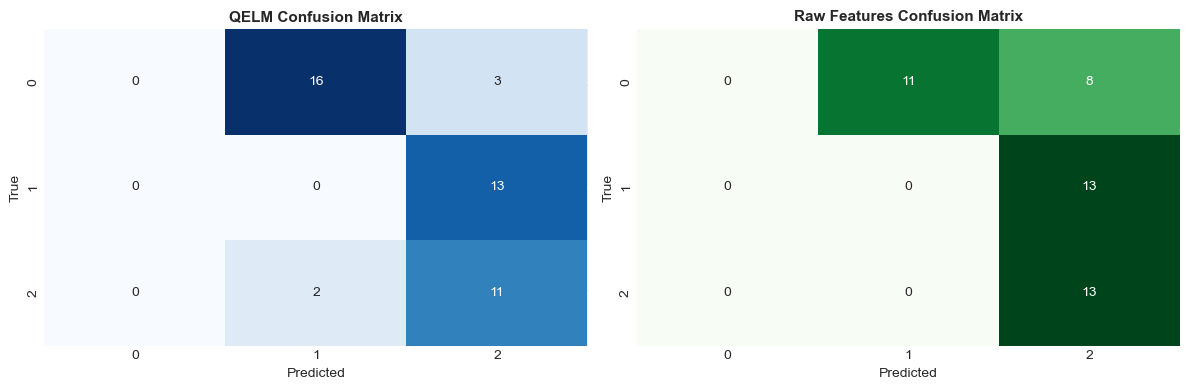

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_qelm = confusion_matrix(y_test_iris, y_pred_qelm)
sns.heatmap(cm_qelm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('QELM Confusion Matrix', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_raw = confusion_matrix(y_test_iris, y_pred_raw_iris)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Raw Features Confusion Matrix', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()